# 03 — Exotic options: Asian, Barrier, Lookback, Digital

Four families of path-dependent instruments behind one contract: every exotic implements
`payoff(paths) -> ndarray` and plugs directly into `MonteCarloEngine.price()` — under GBM
here, and **unchanged** under Heston and rough Bergomi paths in notebooks 04-05.

Each family ships its closed form (Kemna-Vorst, Reiner-Rubinstein, Goldman-Sosin-Gatto,
Black-Scholes digital), so every Monte Carlo price in this notebook is cross-checked against
an independent analytical benchmark, including the **discrete-monitoring continuity
corrections** of Broadie-Glasserman-Kou.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "exotic_option_pricer").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np

np.set_printoptions(precision=6, suppress=True)

from exotic_option_pricer.engines import MonteCarloEngine
from exotic_option_pricer.instruments import AsianOption, BarrierOption, DigitalOption, LookbackOption
from exotic_option_pricer.models import BlackScholesModel

S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
N_STEPS = 252
dt = T / N_STEPS

engine = MonteCarloEngine(n_paths=200_000, n_steps=N_STEPS, seed=42)
paths = engine.simulate_gbm(S0, T, r, sigma)
print(f"paths: {paths.shape}  — one simulation, reused by every instrument below")

paths: (200000, 253)  — one simulation, reused by every instrument below


## Asian options — averaging kills volatility

Fixed-strike arithmetic Asian call: $\big(\tfrac{1}{n}\sum_i S_{t_i} - K\big)^+$. The average
is less volatile than the terminal spot, so the option is cheaper than its European cousin.

The arithmetic average has no closed form, but the **geometric** one does (Kemna-Vorst 1990,
lognormality is preserved under geometric averaging), and the two are highly correlated —
the ideal control variate.

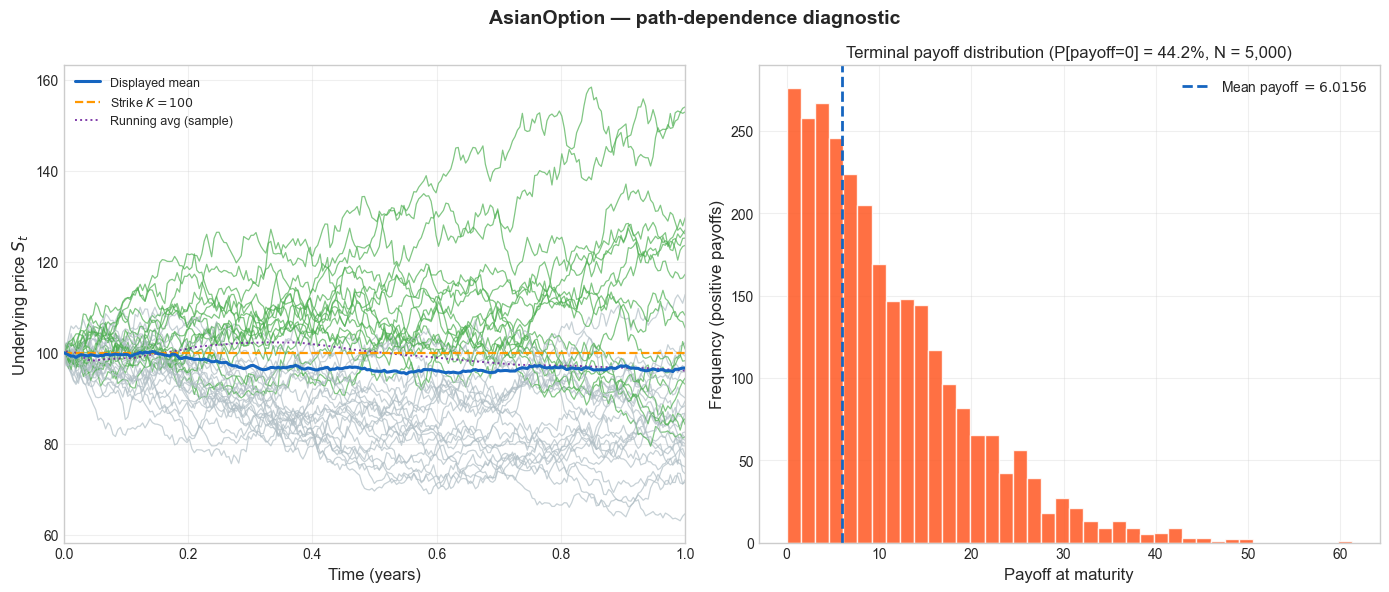

In [2]:
from exotic_option_pricer.utils.visualization import plot_exotic_payoff

asian = AsianOption(K=K, option_type='call', avg_type='arithmetic')
fig = plot_exotic_payoff(asian, S0, T, r, sigma)

In [3]:
# Gold standard first: geometric Asian MC vs Kemna-Vorst closed form
asian_geo = AsianOption(K=K, option_type='call', avg_type='geometric')
kv = AsianOption.geometric_price(S0, K, T, r, sigma, n_obs=N_STEPS)
res_geo = engine.price(asian_geo.payoff, paths, r, T)
z = (res_geo.price - kv) / res_geo.std_error
print(f"geometric MC {res_geo.price:.4f} vs Kemna-Vorst {kv:.4f}   (z = {z:+.2f})")
assert abs(z) < 3

# Arithmetic Asian: plain MC vs geometric-as-control-variate
cv_fn = asian.geometric_control_fn(S0, T, r, sigma, n_obs=N_STEPS)
res_plain = engine.price(asian.payoff, paths, r, T)
res_cv = engine.price(asian.payoff, paths, r, T, control_fn=cv_fn)

ratio = res_cv.std_error / res_plain.std_error
print(f"arithmetic plain: {res_plain.price:.4f}  (SE {res_plain.std_error:.5f})")
print(f"arithmetic + KV control: {res_cv.price:.4f}  (SE {res_cv.std_error:.5f})")
print(f"SE ratio: {ratio:.3f}  -> {100 * (1 - ratio**2):.1f}% of the variance removed")
assert ratio < 0.32

geometric MC 5.5871 vs Kemna-Vorst 5.5655   (z = +1.25)


arithmetic plain: 5.8048  (SE 0.01793)
arithmetic + KV control: 5.7824  (SE 0.00050)
SE ratio: 0.028  -> 99.9% of the variance removed


## Barrier options — and the discrete-monitoring trap

Up-and-out call: a European call that dies if the spot ever touches $H$. Reiner-Rubinstein
(1991) prices the *continuously* monitored contract; Monte Carlo with daily fixings monitors
*discretely* and systematically misses barrier crossings between fixings — the raw comparison
is biased **by construction**. Broadie-Glasserman-Kou (1997) fix it by shifting the barrier:

$$H_{\text{eff}} = H\,e^{\pm\beta\sigma\sqrt{\Delta t}}, \qquad \beta = \tfrac{-\zeta(1/2)}{\sqrt{2\pi}} \approx 0.5826.$$

In [4]:
H = 130.0
barrier_uo = BarrierOption(K=K, barrier=H, barrier_type='up-and-out', option_type='call')
barrier_ui = BarrierOption(K=K, barrier=H, barrier_type='up-and-in', option_type='call')

res_uo = engine.price(barrier_uo.payoff, paths, r, T)

rr_continuous = BarrierOption.analytical_price(S0, K, T, r, sigma, H, 'up-and-out', 'call')
H_eff = BarrierOption.continuity_correction(H, sigma, dt, 'up')
rr_bgk = BarrierOption.analytical_price(S0, K, T, r, sigma, H_eff, 'up-and-out', 'call')

print(f"MC, 252 daily fixings: {res_uo.price:.4f}  (SE {res_uo.std_error:.5f})")
print(f"Reiner-Rubinstein continuous: {rr_continuous:.4f}   <- wrong benchmark for daily fixings")
print(f"RR with BGK barrier {H_eff:.2f}: {rr_bgk:.4f}   <- right benchmark")
z_naive = (res_uo.price - rr_continuous) / res_uo.std_error
z_bgk = (res_uo.price - rr_bgk) / res_uo.std_error
print(f"z vs continuous: {z_naive:+.1f}   |   z vs BGK-corrected: {z_bgk:+.2f}")
assert abs(z_naive) > 3 and abs(z_bgk) < 4

# In-out parity holds path by path on the same simulation: UO + UI = vanilla
res_ui = engine.price(barrier_ui.payoff, paths, r, T)
vanilla = engine.price(lambda p: np.maximum(p[:, -1] - K, 0.0), paths, r, T)
gap = abs((res_uo.price + res_ui.price) - vanilla.price)
print(f"\nin-out parity |UO + UI - vanilla| = {gap:.2e}")
assert gap < 1e-9

MC, 252 daily fixings: 3.5826  (SE 0.01430)
Reiner-Rubinstein continuous: 3.3329   <- wrong benchmark for daily fixings
RR with BGK barrier 130.96: 3.5660   <- right benchmark
z vs continuous: +17.5   |   z vs BGK-corrected: +1.16

in-out parity |UO + UI - vanilla| = 3.55e-15


## Lookback options — buying the minimum

Floating-strike lookback call pays $S_T - \min_t S_t$: you buy at the lowest price the path
ever printed. Goldman-Sosin-Gatto (1979) give the continuous closed form. The same
discrete-monitoring bias appears here — the observed minimum of 252 fixings is *higher* than
the true continuous minimum — and the same $\beta$ fixes it, now applied to the per-path
extremum itself.

In [5]:
lookback = LookbackOption(option_type='call', strike_type='floating')
gsg = LookbackOption.analytical_price(S0, T, r, sigma, 'call', 'floating')

res_raw = engine.price(lookback.payoff, paths, r, T)

def lookback_bgk_payoff(p: np.ndarray) -> np.ndarray:
    m_eff = LookbackOption.continuity_correction(p.min(axis=1), sigma, dt, 'min')
    return p[:, -1] - m_eff

res_bgk = engine.price(lookback_bgk_payoff, paths, r, T)

print(f"Goldman-Sosin-Gatto continuous: {gsg:.4f}")
print(f"MC raw discrete minimum: {res_raw.price:.4f}  (z = {(res_raw.price - gsg) / res_raw.std_error:+.1f})")
print(f"MC with BGK-adjusted minimum: {res_bgk.price:.4f}  (z = {(res_bgk.price - gsg) / res_bgk.std_error:+.2f})")
assert abs(res_bgk.price - gsg) < 4 * res_bgk.std_error

Goldman-Sosin-Gatto continuous: 17.2168
MC raw discrete minimum: 16.6680  (z = -16.8)
MC with BGK-adjusted minimum: 17.2778  (z = +1.86)


## Digital options — all-or-nothing

Cash-or-nothing call pays $1$ if $S_T > K$: worth exactly $e^{-rT} N(d_2)$. Asset-or-nothing
pays $S_T$ itself: worth $S e^{-qT} N(d_1)$. Together they *are* the vanilla call:

$$C_{\text{vanilla}} = \text{AoN} - K \cdot \text{CoN}$$

— which we verify against the Phase 1 engine to machine precision.

In [6]:
digital_cash = DigitalOption(K=K, option_type='call', payout_type='cash')

con = DigitalOption.analytical_price(S0, K, T, r, sigma, 'call', 'cash')
aon = DigitalOption.analytical_price(S0, K, T, r, sigma, 'call', 'asset')
res_digital = engine.price(digital_cash.payoff, paths, r, T)
z = (res_digital.price - con) / res_digital.std_error

print(f"cash-or-nothing MC {res_digital.price:.4f} vs closed form {con:.4f}  (z = {z:+.2f})")
assert abs(z) < 3

vanilla_bs = float(BlackScholesModel(sigma=sigma).price(S0, K, T, r, 'call'))
decomposition_gap = abs((aon - K * con) - vanilla_bs)
print(f"|AoN - K*CoN - C_vanilla| = {decomposition_gap:.2e}")
assert decomposition_gap < 1e-10

cash-or-nothing MC 0.5332 vs closed form 0.5323  (z = +0.88)
|AoN - K*CoN - C_vanilla| = 0.00e+00


## Numerical Greeks for any exotic

No closed-form Greeks exist for an arithmetic Asian — the library computes them by
bump-and-revalue with **common random numbers** (same seed per bump pair) and exact GBM
path rescaling for delta/gamma (one simulation, rescaled — zero resimulation noise).

In [7]:
from exotic_option_pricer.utils.greeks import numerical_greeks

g = numerical_greeks(engine, asian.payoff, S0, T, r, sigma)
for name, value in g.items():
    print(f"{name:>8}: {value:+.5f}")

assert 0.0 < g['delta'] < 1.0
assert g['gamma'] > 0.0
assert g['vega'] > 0.0

   delta: +0.58959
   gamma: +0.03219
    vega: +21.87773
   theta: -3.41718
     rho: +24.58511


---
**Next:** [04 — Heston stochastic volatility](04_heston_stochastic_volatility.ipynb) — same
instruments, no code changes, priced on stochastic-volatility paths.